# Model 4: SVM with RBF Kernel


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import os
os.makedirs('results-svm', exist_ok=True)

In [2]:
def load_and_preprocess():
    train = pd.read_csv('../data/train.csv')
    test  = pd.read_csv('../data/test.csv')

    def engineer(df):
        df = df.copy()
        df['Cabin_Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0] if pd.notna(x) else 'Unknown')
        df['Cabin_Side'] = df['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) else 'Unknown')
        df['Group']      = df['PassengerId'].apply(lambda x: x.split('_')[0])
        df['GroupSize']  = df.groupby('Group')['Group'].transform('count')
        spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
        df['TotalSpending'] = df[spend_cols].sum(axis=1)
        df['NoSpending']    = (df['TotalSpending'] == 0).astype(int)
        df['Age']       = df['Age'].fillna(df['Age'].median())
        df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(int)
        df['VIP']       = df['VIP'].fillna(False).astype(int)
        for c in spend_cols: df[c] = df[c].fillna(0)
        df['HomePlanet']  = df['HomePlanet'].fillna('Unknown')
        df['Destination'] = df['Destination'].fillna('Unknown')
        for c in ['HomePlanet','Destination','Cabin_Deck','Cabin_Side']:
            le = LabelEncoder()
            df[c] = le.fit_transform(df[c].astype(str))
        return df

    features = ['HomePlanet','CryoSleep','Destination','Age','VIP',
                'RoomService','FoodCourt','ShoppingMall','Spa','VRDeck',
                'Cabin_Deck','Cabin_Side','GroupSize','TotalSpending','NoSpending']

    train_e = engineer(train)
    test_e  = engineer(test)
    X = train_e[features]
    y = train_e['Transported'].astype(int)
    X_test_final = test_e[features]

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test_final)
    return X_train_s, X_val_s, y_train, y_val, X_test_s, test['PassengerId']

X_train, X_val, y_train, y_val, X_test, passenger_ids = load_and_preprocess()
print('Data loaded.')

Data loaded.


## Hyperparameter Tuning: Grid Search (C, gamma)

In [3]:
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
grid = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print(f'Best params : {grid.best_params_}')
print(f'Best CV acc : {grid.best_score_:.4f}')

Best params : {'C': 10, 'gamma': 0.1}
Best CV acc : 0.7944


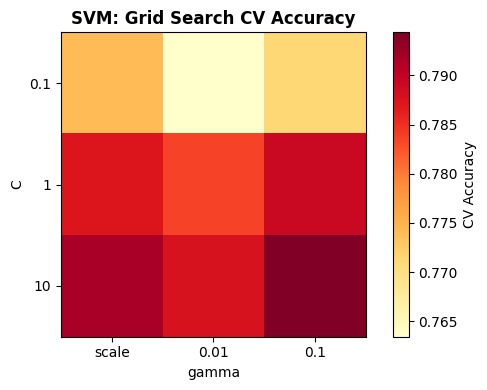

In [4]:
scores = grid.cv_results_['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['gamma']))
plt.figure(figsize=(6,4))
plt.imshow(scores, interpolation='nearest', cmap='YlOrRd', vmin=scores.min(), vmax=scores.max())
plt.colorbar(label='CV Accuracy')
plt.xticks(range(len(param_grid['gamma'])), param_grid['gamma'])
plt.yticks(range(len(param_grid['C'])), param_grid['C'])
plt.xlabel('gamma'); plt.ylabel('C')
plt.title('SVM: Grid Search CV Accuracy', fontweight='bold')
plt.tight_layout()
plt.savefig('results-svm/04_svm_gridsearch.png', dpi=150)
plt.show()

## Train Final Model & Evaluate

In [5]:
svm = grid.best_estimator_
y_pred = svm.predict(X_val)
cv     = cross_val_score(svm, X_train, y_train, cv=5)

print(f'Validation Accuracy : {accuracy_score(y_val, y_pred):.4f}')
print(f'CV Accuracy         : {cv.mean():.4f} ± {cv.std():.4f}')
print()
print(classification_report(y_val, y_pred, target_names=['Not Transported','Transported']))

Validation Accuracy : 0.7855
CV Accuracy         : 0.7944 ± 0.0075

                 precision    recall  f1-score   support

Not Transported       0.79      0.78      0.78       863
    Transported       0.78      0.79      0.79       876

       accuracy                           0.79      1739
      macro avg       0.79      0.79      0.79      1739
   weighted avg       0.79      0.79      0.79      1739



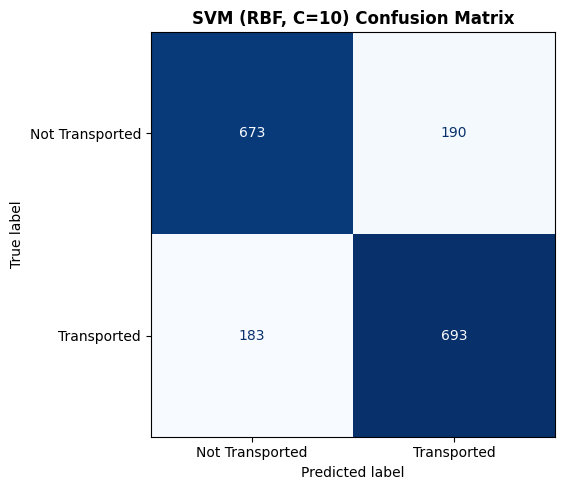

In [6]:
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Transported','Transported'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'SVM (RBF, C={grid.best_params_["C"]}) Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('results-svm/04_confusion_matrix.png', dpi=150)
plt.show()

## Kaggle Submission

In [7]:
preds = svm.predict(X_test)
submission = pd.DataFrame({'PassengerId': passenger_ids, 'Transported': preds.astype(bool)})
submission.to_csv('results-svm/04_svm_submission.csv', index=False)
print('Submission saved: results-svm/04_svm_submission.csv')
submission.head()

Submission saved: results-svm/04_svm_submission.csv


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
